# Procedural Terrain Generation for MuJoCo

![Project Banner](./media/lab4_poster.png)

A modular terrain generator for creating diverse simulation environments for legged robotics. This project implements procedural generation of stairs, rough ground, and Perlin noise-based heightfields, designed to improve domain randomization and sim-to-real transfer for locomotion policies.

**Author:** Nandan Natesan

## Setup

In [1]:
import sys, types, importlib

# Create a tiny fake 'imp' module exposing only 'reload'
_imp = types.ModuleType("imp")
_imp.reload = importlib.reload
sys.modules["imp"] = _imp

# load autoreload
%load_ext autoreload
%autoreload 2

In [2]:
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl
%env XLA_PYTHON_CLIENT_PREALLOCATE=false

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
env: XLA_PYTHON_CLIENT_PREALLOCATE=false


In [3]:
#@title Import packages for plotting and creating graphics
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.1 MB/s eta 0:00:00


### Google Colab Setup

Next, we'll run a few fommands to set up the environment on Google Colab. If you are running this notebook locally you can skip this section

Run the following to mount this notebook to your Google Drive. Follow the link and sign into the Google account following the prompts. Use the same Google account that you used to store this notebook.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now update the path below to point to the folder in your Google Drive where you uploaded this notebook. If everything worked correctly you should see the following filenames: [`custom_env.py`, `02_lab.ipynb`]

In [ ]:
import os

# For Google Colab: mount drive first, then set path to this project folder
# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', 'your-folder-path')
# sys.path.append(GOOGLE_DRIVE_PATH)
# os.chdir(GOOGLE_DRIVE_PATH)

# For local runs, ensure you're in the project root directory.


In [29]:
!ls

04_lab_student.ipynb  media	      terrain_generator_student.py
custom_env.py	      out_bitmap.png
google_barkour_vb     __pycache__


In [30]:
!pwd

/content/drive/My Drive/CSE_598/lab4-terrain-randomization


In [31]:
from google.colab import files

import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")



Ensure that everything is installed properly

In [32]:
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install noise
!pip install warp-lang

In [33]:
import os

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Checking that the installation succeeded:
Installation successful.


## Mujoco Setup & Imports

In [34]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from ml_collections import config_dict


import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model

import cv2

## Randomizing Model Properties in Mujoco Playground

We might want to include randomization over certain `mjModel` parameters while training different policies. In MJX, we can easily create a **batch** of environments with randomized values populated in `mjx.Model`. Below, you will impliment a simple function that randomizes friction and actuator gain/bias.

`TODO(student):` Impliment the function below to randomize friction in the environment **(10 pts)**

In [35]:
def domain_randomize(sys, rng):
  """Randomizes the mjx.Model."""

  @jax.vmap
  def rand(rng):
    '''
    Returns randomized friction and actuator parameters.
    '''

    _, key = jax.random.split(rng, 2)

    # TODO(student): Randomize the friction parameters and actuator parameters.
    # friction ~ U(0.6, 1.4)
    # HINT: you can use sys.geom_friction to access the friction values of geoms

    # friction randomization
    friction = jax.random.uniform(
        key,
        sys.geom_friction.shape,
        minval=0.6,
        maxval=1.4
    )
    friction = sys.geom_friction.at[:].set(friction)

    # actuator randomization (already implimented)
    _, key = jax.random.split(key, 2)
    gain_range = (-5, 5)
    param = jax.random.uniform(
        key, (1,), minval=gain_range[0], maxval=gain_range[1]
    ) + sys.actuator_gainprm[:, 0]
    gain = sys.actuator_gainprm.at[:, 0].set(param)
    bias = sys.actuator_biasprm.at[:, 1].set(-param)

    return friction, gain, bias

  friction, gain, bias = rand(rng)

  in_axes = jax.tree_util.tree_map(lambda x: None, sys)

  #TODO(student): Update the in_axes and sys model below...
  in_axes = in_axes.tree_replace({
      'geom_friction': 0,
      'actuator_gainprm': 0,
      'actuator_biasprm': 0,
  })

  sys = sys.tree_replace({
      'geom_friction': friction,
      'actuator_gainprm': gain,
      'actuator_biasprm': bias,
  })

  return sys, in_axes

In [36]:
from custom_env import GoogleBarkourEnv
envs.register_environment('barkour', GoogleBarkourEnv)
env = envs.get_environment("barkour")

rng = jax.random.PRNGKey(0)
rng = jax.random.split(rng, 10)
batched_sys, _ = domain_randomize(env.sys, rng)

print('Single env friction shape: ', env.sys.geom_friction.shape)
print('Batched env friction shape: ', batched_sys.geom_friction.shape)

print('Friction on geom 0: ', env.sys.geom_friction[0, 0])
print('Random frictions on geom 0: ', batched_sys.geom_friction[:, 0, 0])

/usr/local/lib/python3.12/dist-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


Single env friction shape:  (30, 3)
Batched env friction shape:  (10, 30, 3)
Friction on geom 0:  1.0
Random frictions on geom 0:  [0.683 0.673 1.197 1.279 1.088 1.398 0.9   0.611 0.766 0.65 ]


**Understanding `@jax.vmap`:** The `@jax.vmap` decorator vectorizes a function so it runs on a batch of inputs at once. Here it applies `rand` to all random keys in parallel, producing many sets of randomized friction and actuator parameters in one call—hence the batched system has an extra dimension.


## Procedurally Generating Terrain

In this section, we'll explore how to procedurally generate terrains to spawn in our environment. We will do this by modifying the [`scene_mjx.xml`](./google_barkour_vb/barkour_vb_mjx.xml) files provided in this lab. First, you'll create a modular "terrain element builder" which is capable of procedurally generating terrain elements (i.e. slopes, heightfields, boxes, cyllinders, and stairs). Next, we'll explore how to intelligently place these scene elements in the scene

First, let's render a simple environment with a good view of the entire scene.

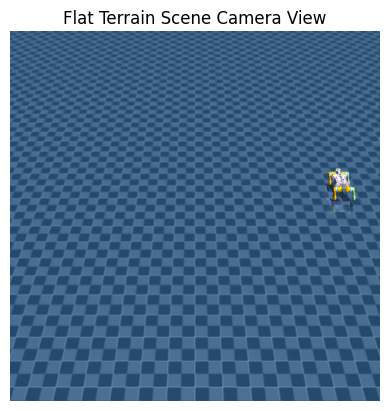

In [37]:
from custom_env import GoogleBarkourEnv
envs.register_environment('barkour', GoogleBarkourEnv)
env = envs.get_environment("barkour")

# jit reset/step functions for fast runtime
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

state = jit_reset(jax.random.PRNGKey(0))

img = env.render([state.pipeline_state], camera='scene', width=480, height=480)[0]
plt.imshow(img)
plt.title("Flat Terrain Scene Camera View")
plt.axis("off")
plt.show()

The `TerrainGenerator` class in `terrain_generator.py` provides methods to add procedural obstacles. Use the code below to generate a modified XML:


In [41]:
from terrain_generator import TerrainGenerator

input_scene_path = "./google_barkour_vb/scene_mjx.xml"
output_scene_path = "./google_barkour_vb/scene_mjx_with_terrain.xml"
tg = TerrainGenerator(input_scene_path, output_scene_path)

# Box obstacle
tg.AddBox(position=[1.5, 0.0, 0.1], euler=[0, 0, 0.0], size=[1, 1.5, 0.2])

# Geometry obstacle
# geo_type supports "plane", "sphere", "capsule", "ellipsoid", "cylinder", "box"
tg.AddGeometry(position=[1.5, 0.0, 0.25], euler=[0, 0, 0.0], size=[1.0,0.5,0.5],geo_type="cylinder")

# Slope
tg.AddBox(position=[2.0, 2.0, 0.5],
            euler=[0.0, -0.5, 0.0],
            size=[3, 1.5, 0.1])

# Stairs
tg.AddStairs(init_pos=[1.0, 4.0, 0.0], yaw=0.0)

# Rough ground
tg.AddRoughGround(init_pos=[-2.5, 5.0, 0.0],
                    euler=[0, 0, 0.0],
                    nums=[10, 8])

# Perlin heigh field
tg.AddPerlinHeighField(position=[-1.5, 4.0, 0.0], size=[2.0, 1.5])

# Heigh field from image
tg.AddHeighFieldFromImage(position=[-1.5, 2.0, 0.0],
                          euler=[0, 0, -1.57],
                          size=[2.0,2.0],
                          input_img="./unitree_robot.jpeg",
                          image_scale=[1.0, 1.0],
                          output_hfield_image="unitree_hfield.png")

tg.CustomTerrain()

tg.Save()




Not Implimented: AddHeighFieldFromImage
Not Implimented: CustomTerrain


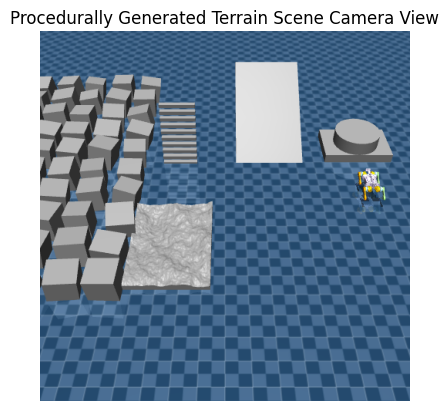

In [42]:
env = envs.get_environment("barkour", scene_file="scene_mjx_with_terrain.xml")

# jit reset/step functions for fast runtime
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

state = jit_reset(jax.random.PRNGKey(0))

img = env.render([state.pipeline_state], camera='scene', width=480, height=480)[0]
plt.imshow(img)
plt.title("Procedurally Generated Terrain Scene Camera View")
plt.axis("off")
plt.show()

## Extending the Generator

Override `CustomTerrain()` in `TerrainGenerator` to add your own procedural components. For more advanced terrain patterns, explore [Wave Function Collapse](https://github.com/ikarth/wfc_2019f) or the [terrain-generator repository](https://github.com/leggedrobotics/terrain-generator).
